# Machine Learning Project

## ETL - Lila

In [96]:
# import necessary libraries
import pandas as pd
import glob
from datetime import datetime

#### Extract Function

In [97]:
## creating the extract function 

def extract(cols) -> pd.DataFrame:
    """This functions combines all the csv, json, and parquet files into a dataframe

    Args:
        cols (list): A list of column names for the resulting dataframe
        
    Returns:
        data (pd.DataFrame): All data sources combined in a single dataframe
    """
    ## create an empty dataframe to hold all the data
    # The columns' names are given based on an earlier exploration of a csv file
    data = pd.DataFrame(columns= cols)
    
    
    for csvfile in glob.glob('final_project_data_sp2026_L/*.csv'):
        # load the current csv file into a temporary dataframe
        tmp_df = pd.read_csv(csvfile)
        
        # concatenate the loaded data with the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)
    

    for jsonfile in glob.glob('final_project_data_sp2026_L/*.json'):
        # load the current json file into a temporary dataframe
        tmp_df = pd.read_json(jsonfile, lines=True)
        
        # concatenate the loaded data to the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)

    for parquetfile in glob.glob('final_project_data_sp2026_L/*.parquet'):
        # load the current parquet file into a temporary dataframe
        tmp_df = pd.read_parquet(parquetfile)
        
        # concatenate the loaded data to the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)

    # return the combined (extracted) data
    return data

#### Transform Function

In [98]:
def transform(data: pd.DataFrame) -> pd.DataFrame:
    """This function performs the transformations:
    1. Fix column names and remove leading spaces 
    2. Converts all columns (except `Label`) to float type
    3. Removing duplicates from the extracted data
    4. Handling missing data
    5. creating new column for benign vs attack based on 'Label' column (all Dos become attack regardless of type)

    Args:
        data (pd.DataFrame): extracted data ready for transformations

    Returns:
        pd.DataFrame: transformed data
    """
    # Task 1: Fix column labels to remove leading spaces
    data.columns = data.columns.str.strip()

    # Task 2: Convert all columns (except `Label`) to float type
    # use the method astype() to convert the data type of the columns
    
    data = data.astype({col: 'float64' for col in data.columns if col != 'Label'})

    # Task 3: Remove duplicates
    # use the method drop_duplicated()
    data = data.drop_duplicates()
    
    # Task 4: Handle missing data
    # use the method dropna() to drop rows with missing values
    data = data.dropna()

    # Task 5: Create new column for benign vs attack based on 'Label' column (all Dos become attack regardless of type)
    # use the method apply() to create a new column 'Attack_Type' based on the values in the 'Label' column
    # benign = 0, attack = 1
    data['Attack_Type'] = data['Label'].apply(lambda x: 1 if x != 'BENIGN' else 0)

    # return transformed data
    return data

#### Load Function

In [99]:
def loadcsv(data: pd.DataFrame) -> None:
    """This function loads the argument dataframe into a csv file

    Args:
        data (pd.DataFrame): extracted nd transformed dataframe
    """
    data.to_csv('all_ids.csv', index=False)

#### Logging Function

In [100]:
def log(message: str) -> None:
    """This function writes the message 'message' and time of occurrence into the file logfile.

    Args:
        logfile (str): log file
        message (str): message to be written into the log file
    """
    # datetime format. Remark that:
    ## .%f appends the parts of the second
    ## the tailing ', ' are intentionally used to separate the timestamp and the logged message
    datatime_format = '%Y-%m-%d-%H:%M:%S.%f, '
    datetimestamp = datetime.now().strftime(datatime_format)
    
    ## log events are separated by the new character
    with open('ETL.log', 'a') as file:
        file.write(datetimestamp + message + '\n')

### Running the ETL Pipeline

In [101]:
## Load in one file to get the column names:

df = pd.read_csv('final_project_data_sp2026_L/ids_0.csv')

# get column names as a list to be used in the extract function
columns = df.columns.tolist()

# checking data types and the first few rows of the data frame
print(df.dtypes)
df.head()

# get the number of nan values in the data frame
nan_counts = df.isna().sum()
print(nan_counts)

 Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
 Label                          object
Length: 79, dtype: object
 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64


In [102]:
log("ETL Pipeline Started")

log("Extract Phase Started")
data = extract(columns)
log("Extract Phase Ended")

log("Transform Phase Started")
data = transform(data)
log("Transform Phase Ended")

log("Load Phase (csv) Started")
loadcsv(data)
log("Load Phase (csv) Ended")

/var/folders/kr/7zrht_xd51zgls9528qw27nh0000gn/T/ipykernel_56702/1911183125.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, tmp_df], ignore_index=True)


### End of ETL 

# EDA - Megan

### Identifying the shape of the dataset

In [103]:
print(f'data shape: {data.shape}')
print(f'dataset size: {data.shape[0]}\nnumber of features: {data.shape[1]}')

data shape: (49362, 80)
dataset size: 49362
number of features: 80


### Unify the columns/feature names

In [104]:
# first - checking if there are repeat feature names
print(len(df.columns))
print(len(set(df.columns)))

# checking the naming conventions
print(data.columns)

# since some columns use spaces and some use underscores, I am going to unify the names so that everything uses underscores
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace(' ', '_')
print(data.columns)

79
79
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN F

### Identifying Unique Values in the Class Label Variable

In [105]:
# original response column
print("Unique Values in the Class Label:",str(data['Label'].unique()))
# new response column (transformed to be binary)
print('Unique Values in Attack Type', str(data['Attack_Type'].unique()))

Unique Values in the Class Label: ['BENIGN' 'DoS Hulk' 'DoS Slowhttptest' 'Heartbleed' 'DoS GoldenEye']
Unique Values in Attack Type [0 1]


### Identifying if the Dataset has Missing Data

In [106]:
print(data.isna().sum())
print(f'Total number of missing values: {data.isna().sum().sum()}')

Destination_Port               0
Flow_Duration                  0
Total_Fwd_Packets              0
Total_Backward_Packets         0
Total_Length_of_Fwd_Packets    0
                              ..
Idle_Std                       0
Idle_Max                       0
Idle_Min                       0
Label                          0
Attack_Type                    0
Length: 80, dtype: int64
Total number of missing values: 0


This dataset does not have missing data.

### Identifying columns with a high percentage of missing data
There are no columns with a high percentage of missing data, as there is no missing data in this dataset.

### Performing Univariate Analysis

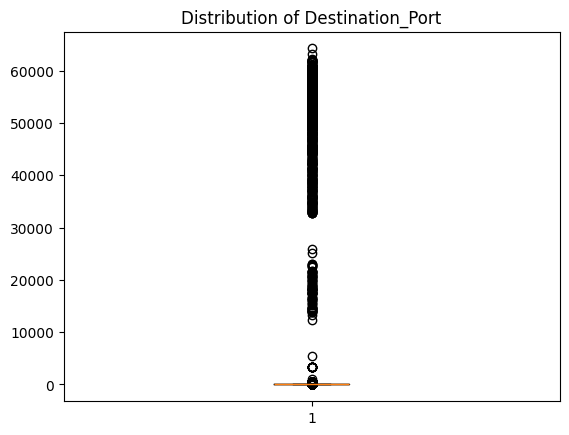

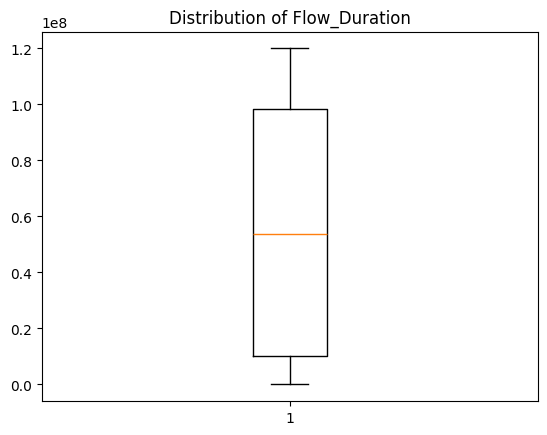

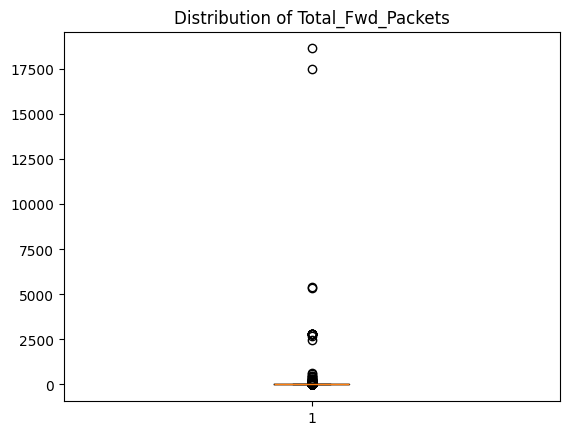

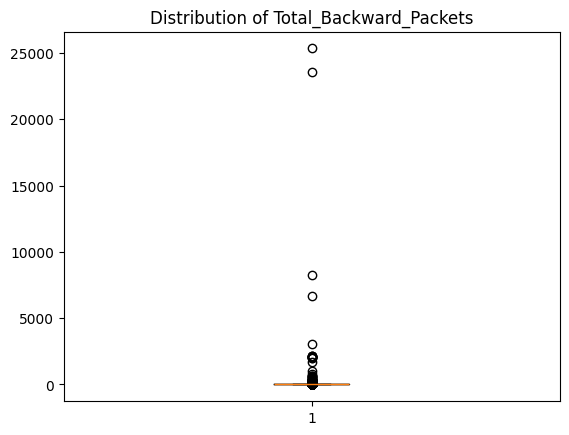

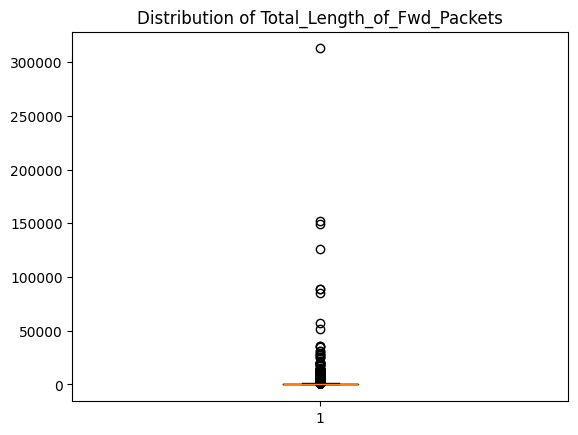

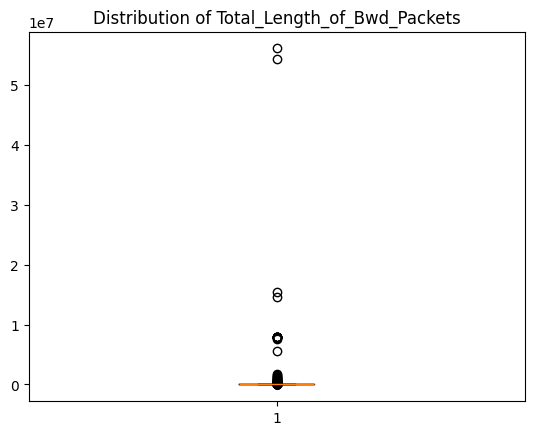

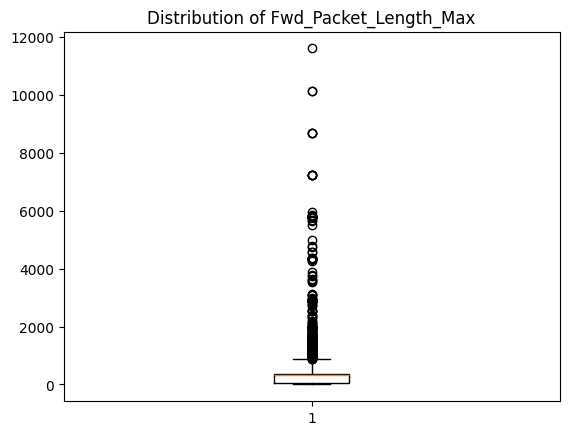

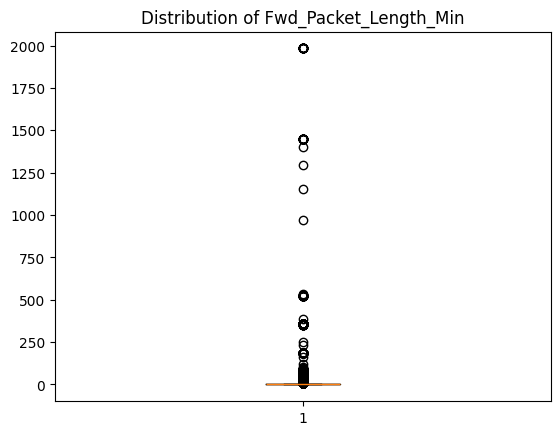

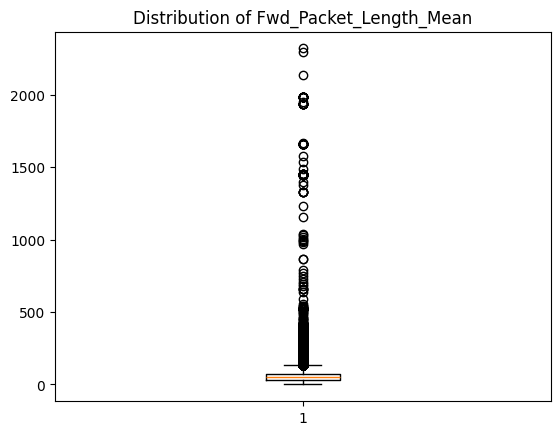

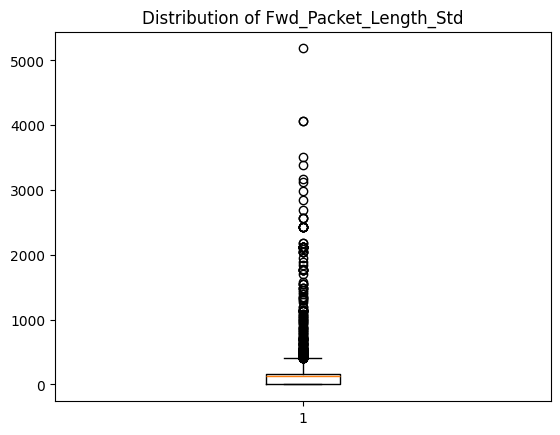

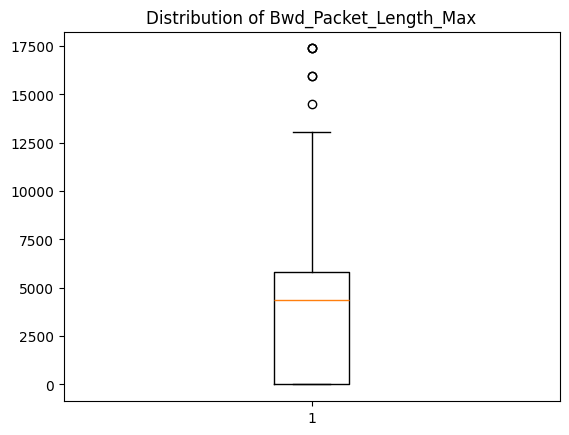

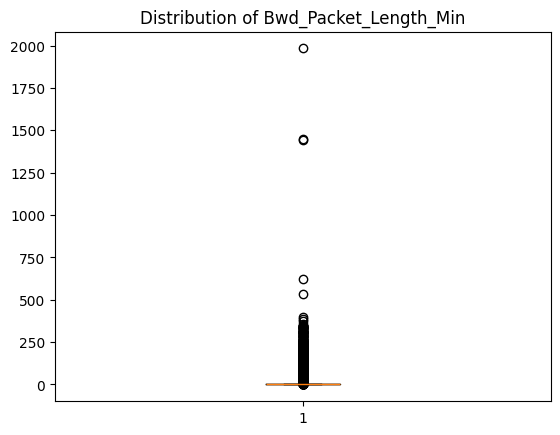

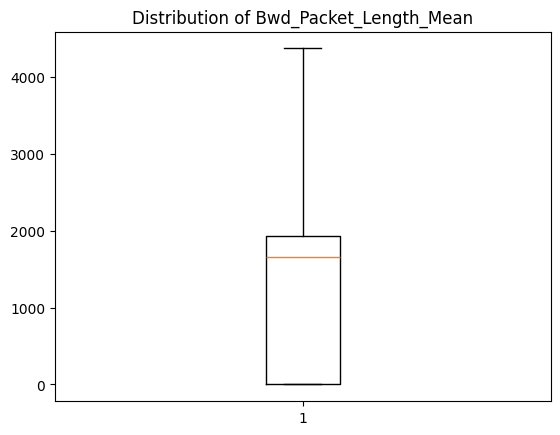

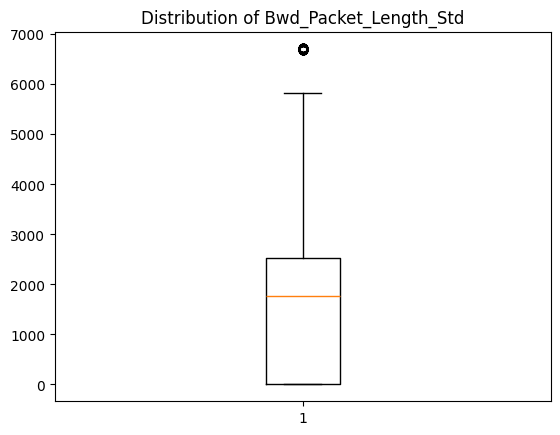

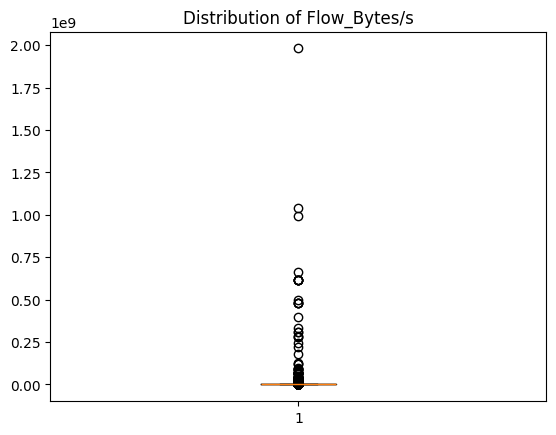

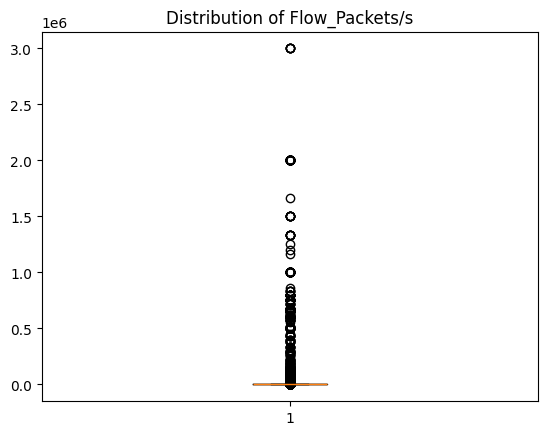

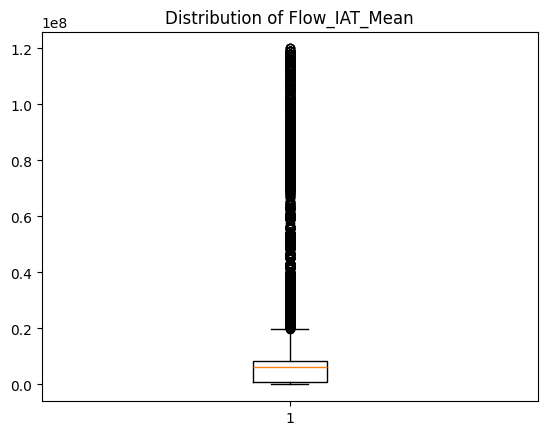

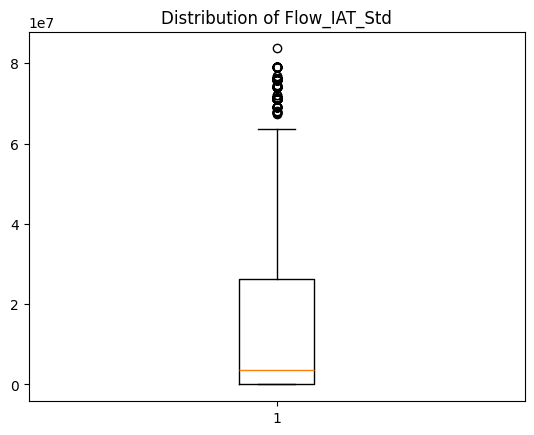

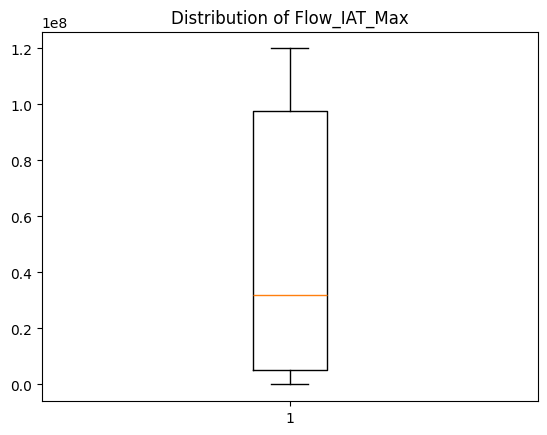

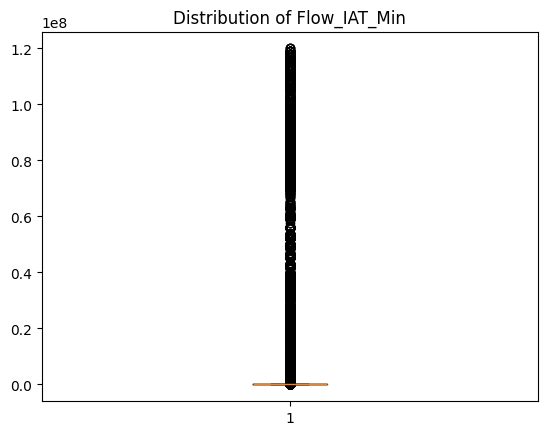

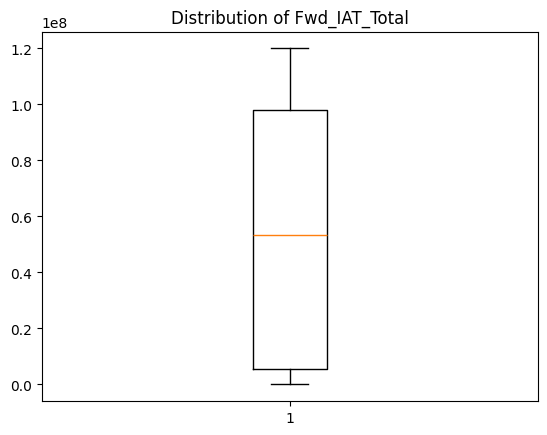

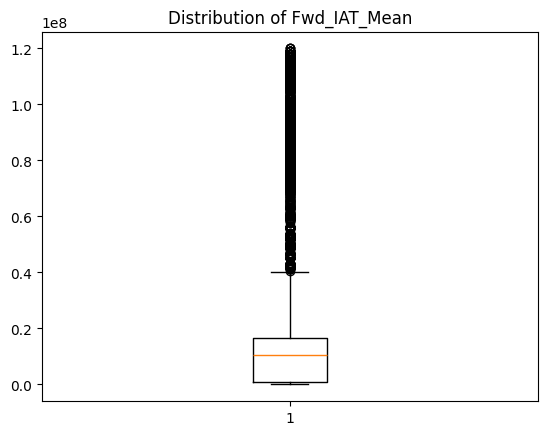

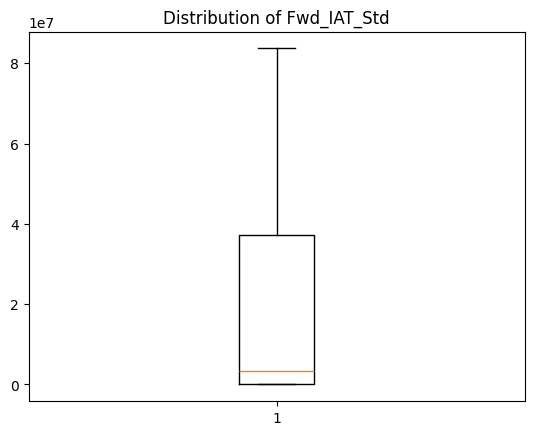

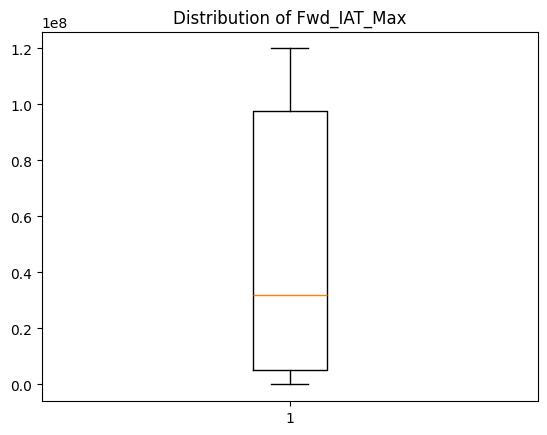

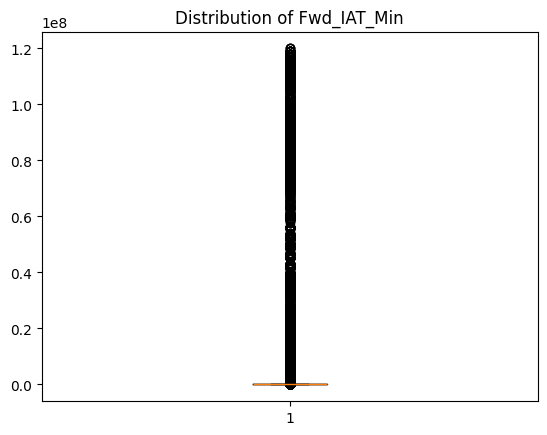

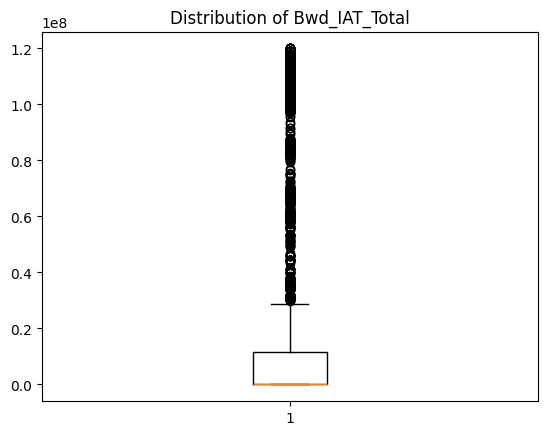

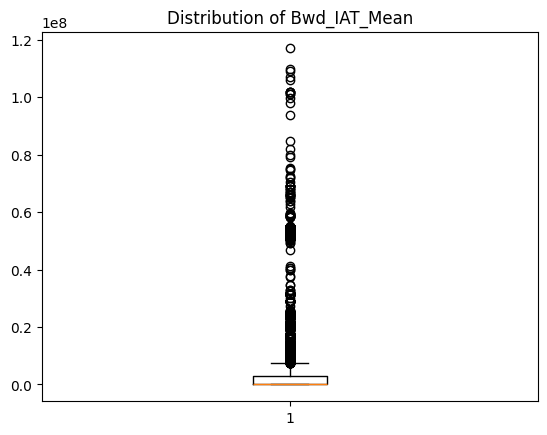

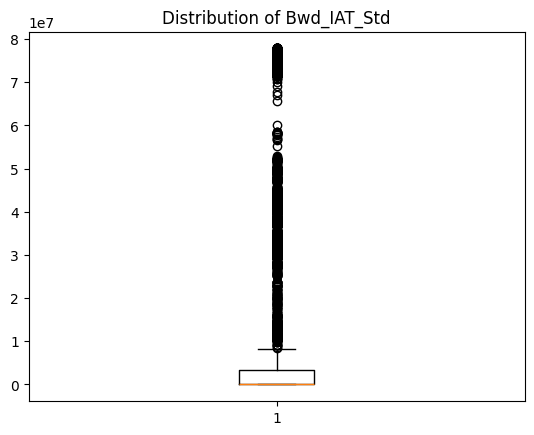

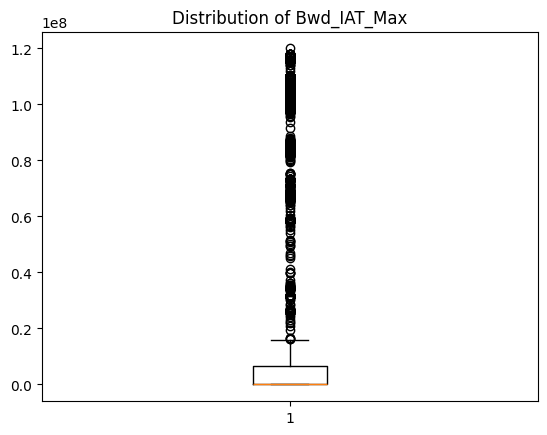

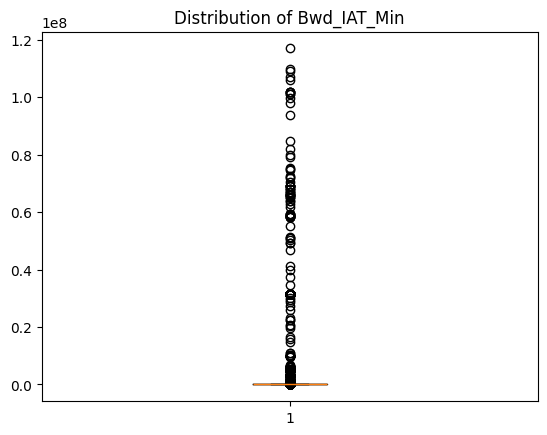

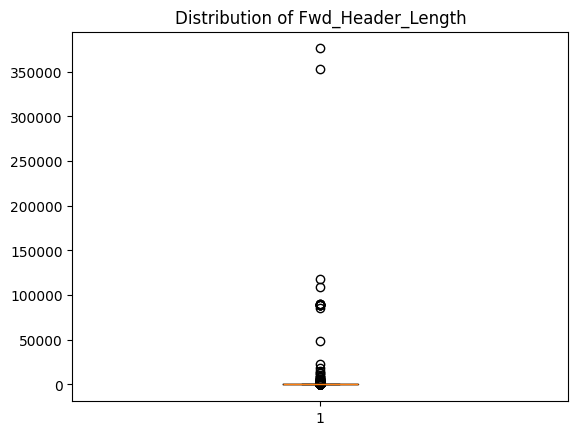

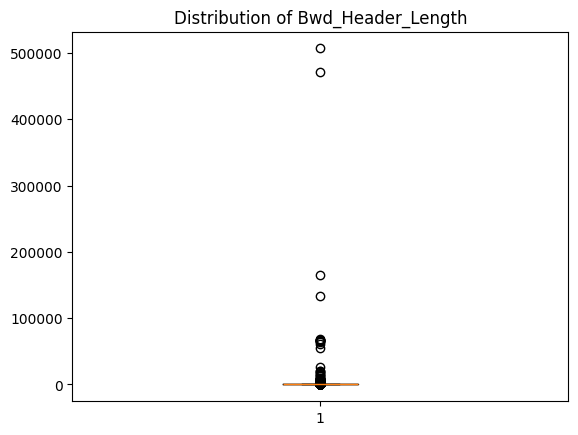

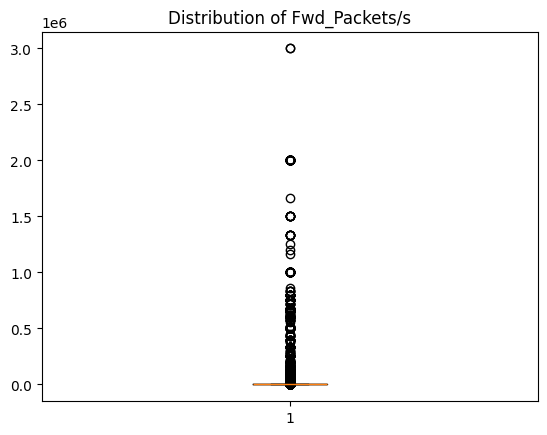

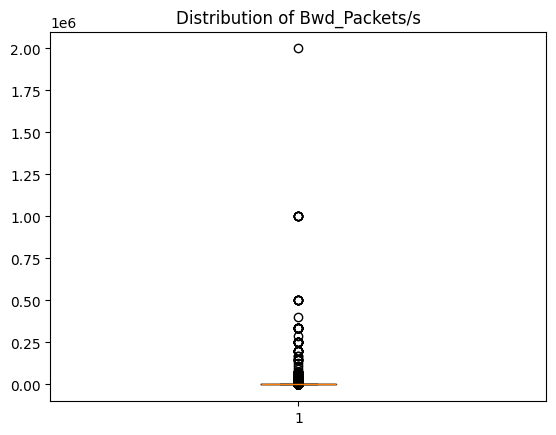

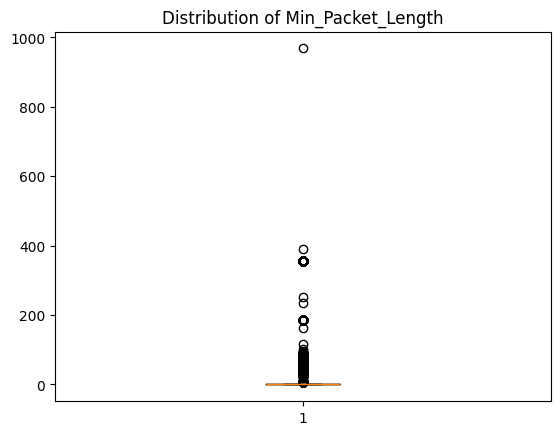

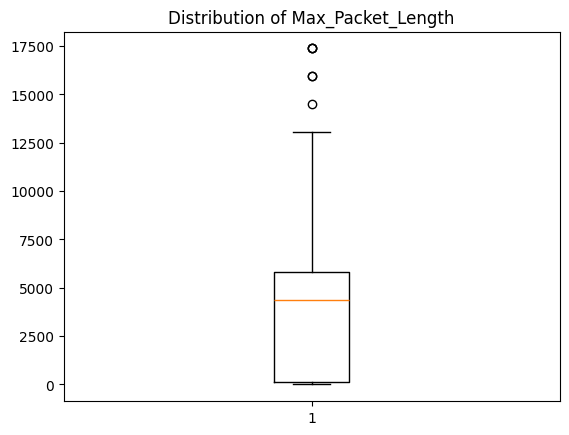

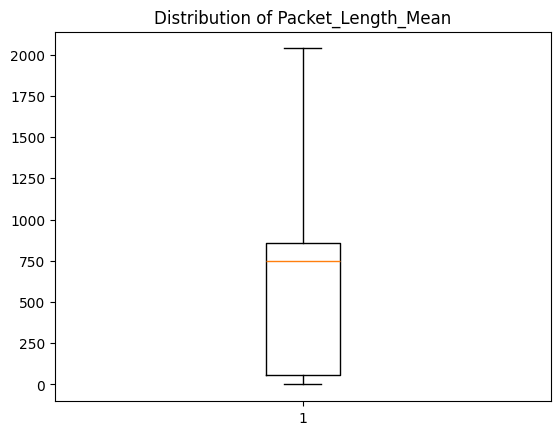

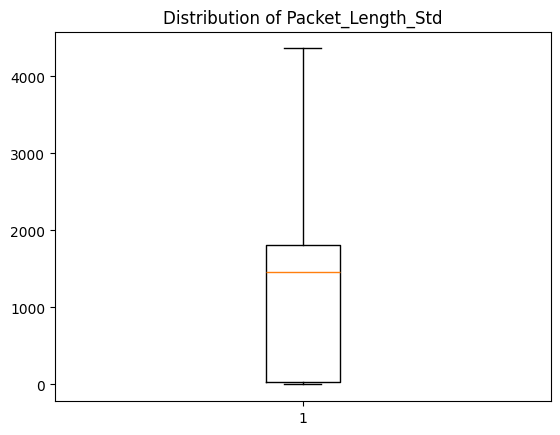

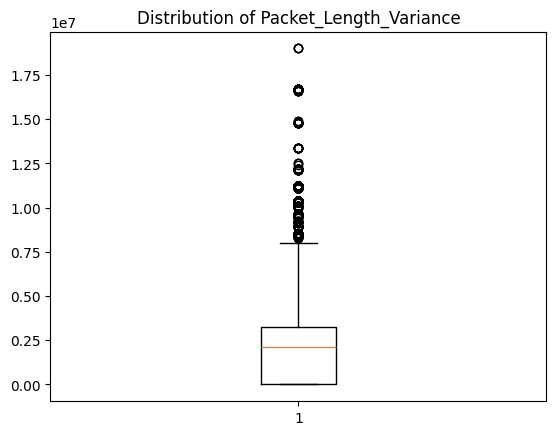

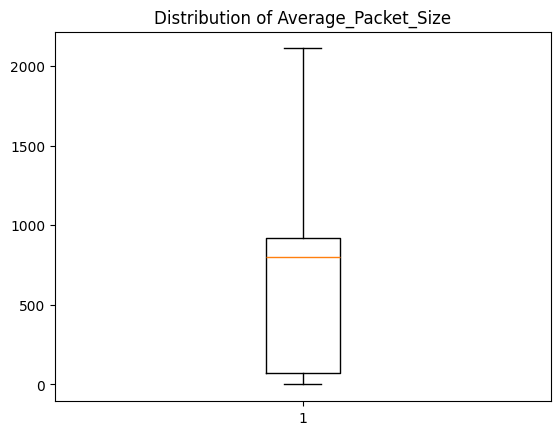

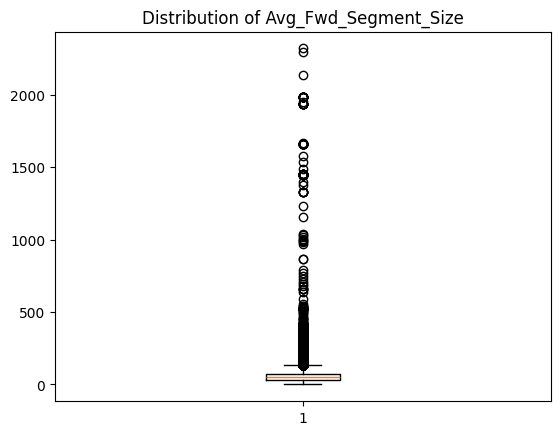

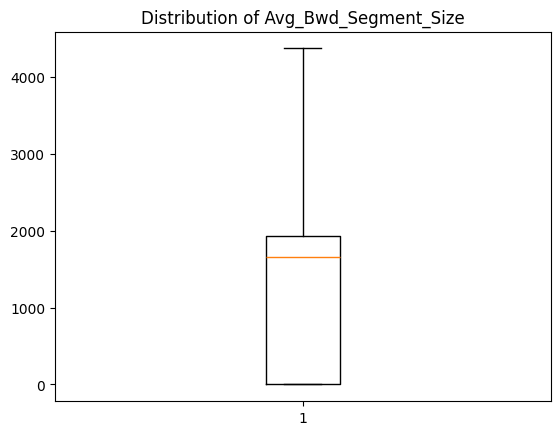

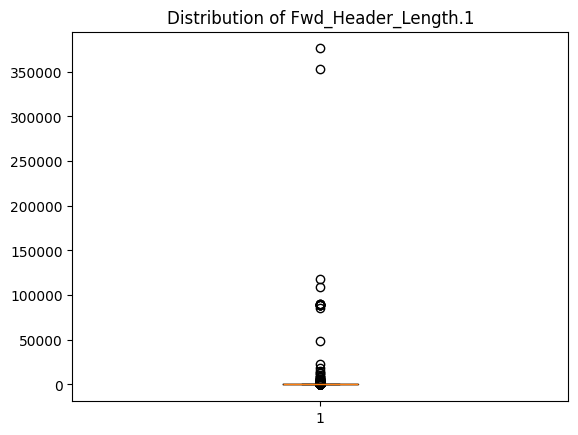

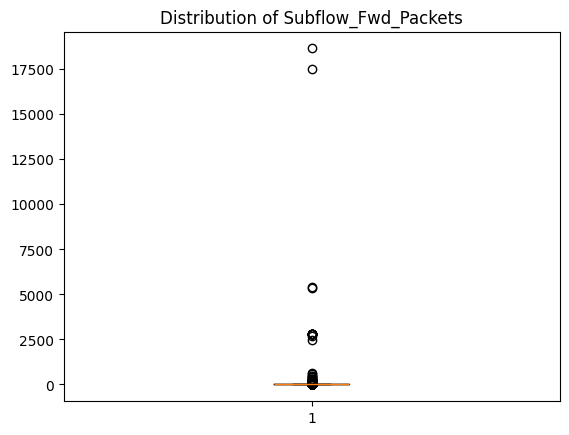

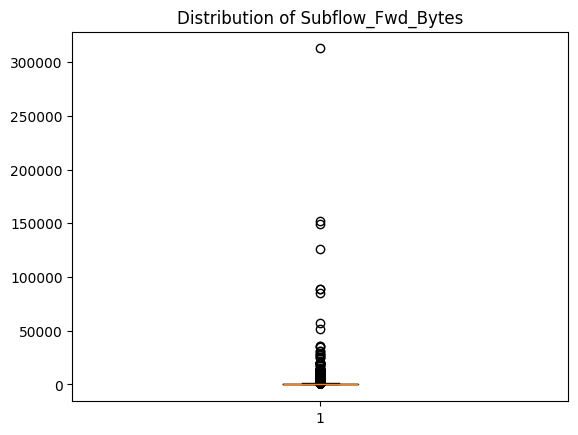

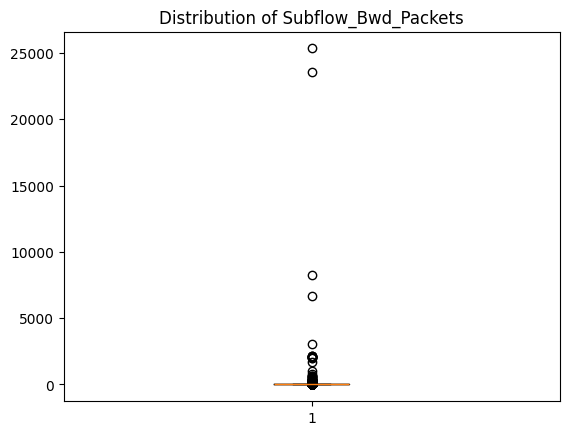

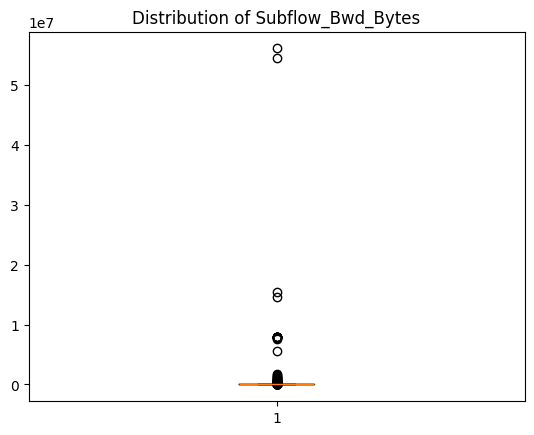

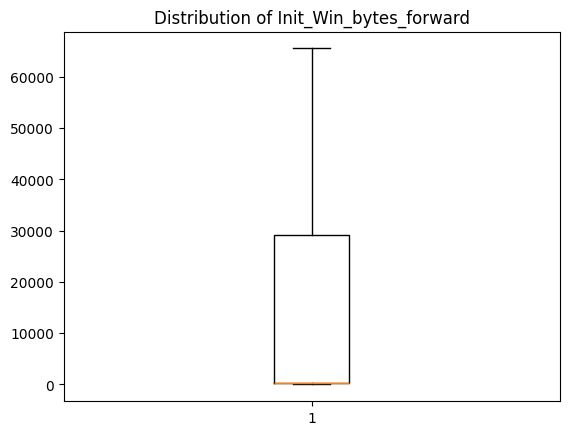

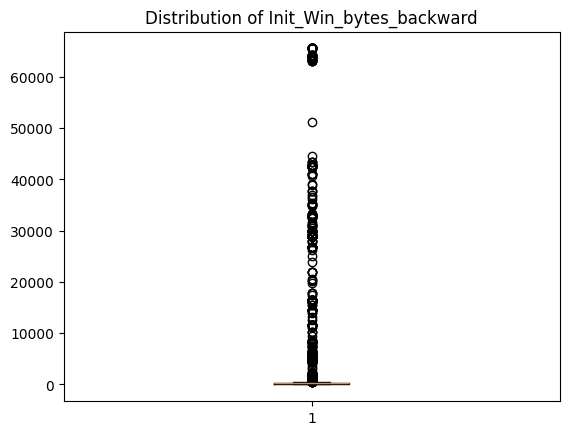

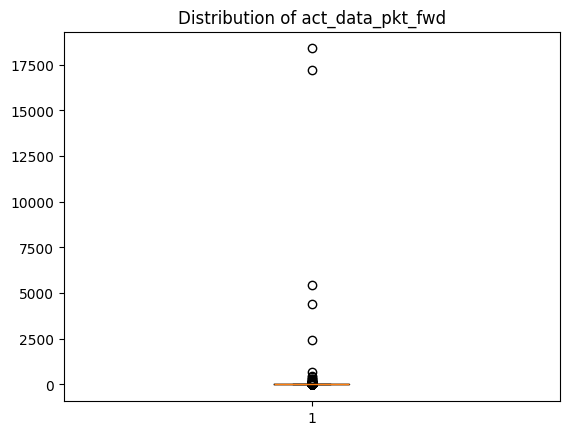

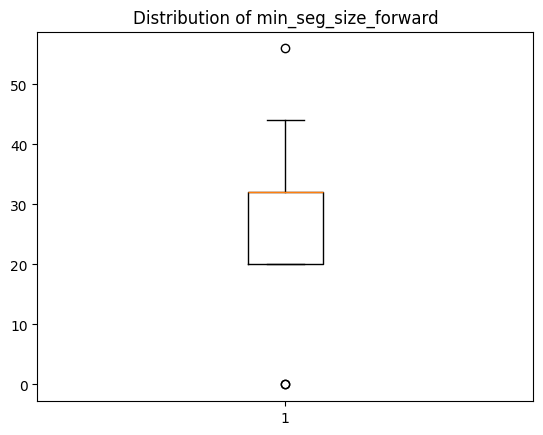

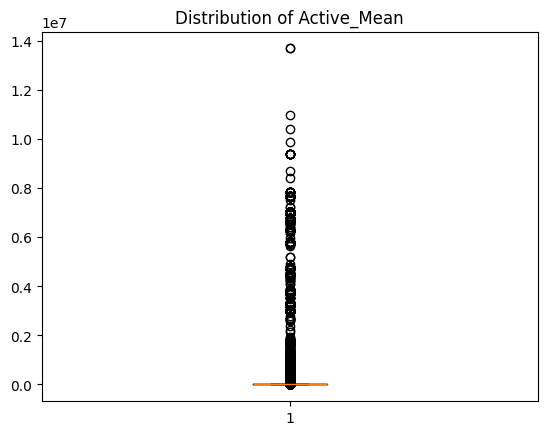

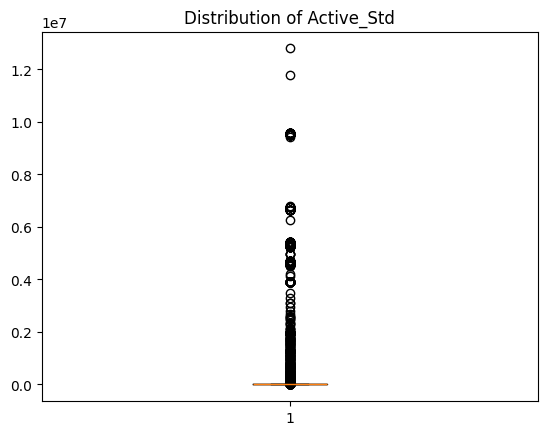

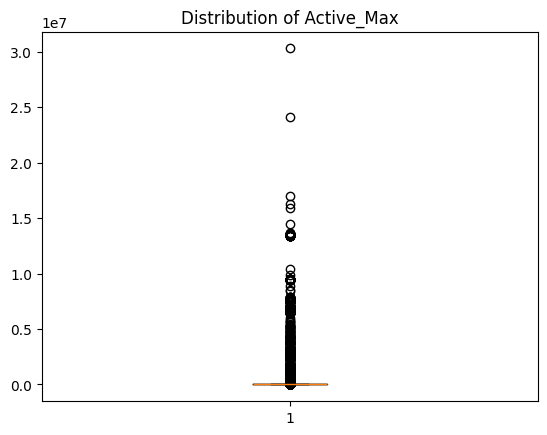

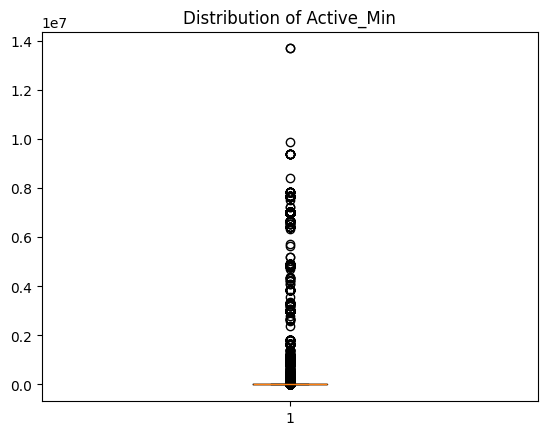

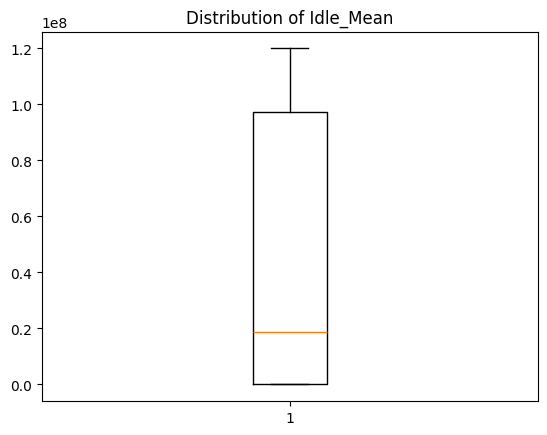

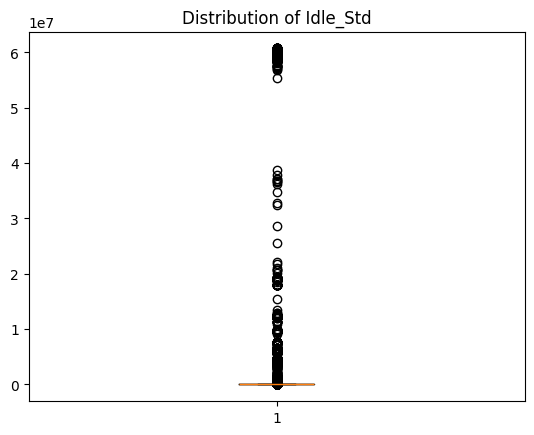

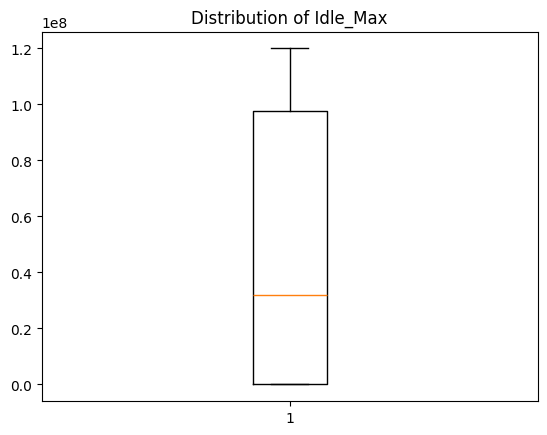

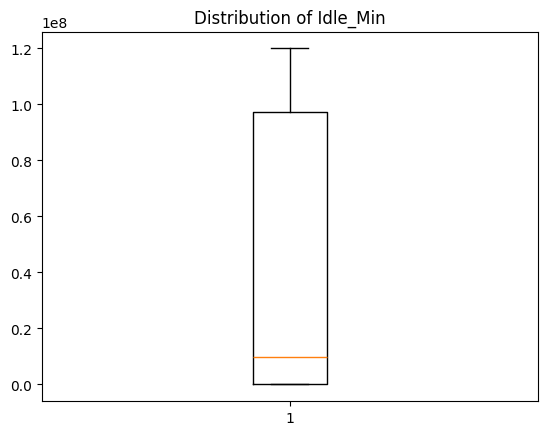

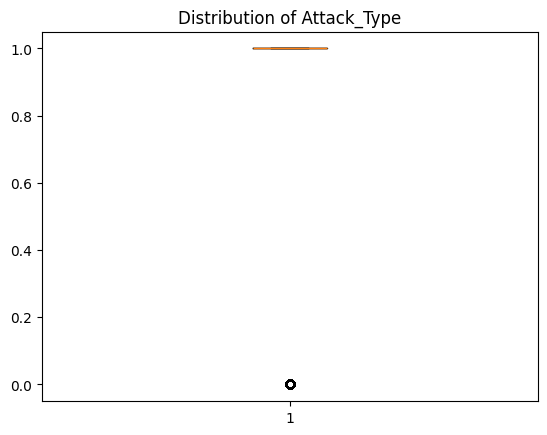

In [107]:
# things I need to import later
import matplotlib.pyplot as plt
import numpy as np

# Finding the statistics of columns
column_stats = data.describe()
column_stats

# examining the variances
variances = data.var(numeric_only=True)
variances.sort_values().head(30) # there is a big jump in variance from less than 1 to 35. 
variances.describe()

# dropping columns with variances less than one
to_drop = variances[variances < 1].index
to_drop = to_drop[to_drop != "Attack_Type"] # making sure the response value is maintained
data = data.drop(columns=to_drop)

# issues with infinite data type. replacing them with nas then dropping nas
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

# visualizing - plotting each column seperately for clarity

for col in data.columns:
    if data[col].dtype in ['int64', 'float64']:
        plt.figure()
        plt.boxplot(data[col])
        plt.title(f'Distribution of {col}')
        plt.show()





    


### Performing bivariate analysis

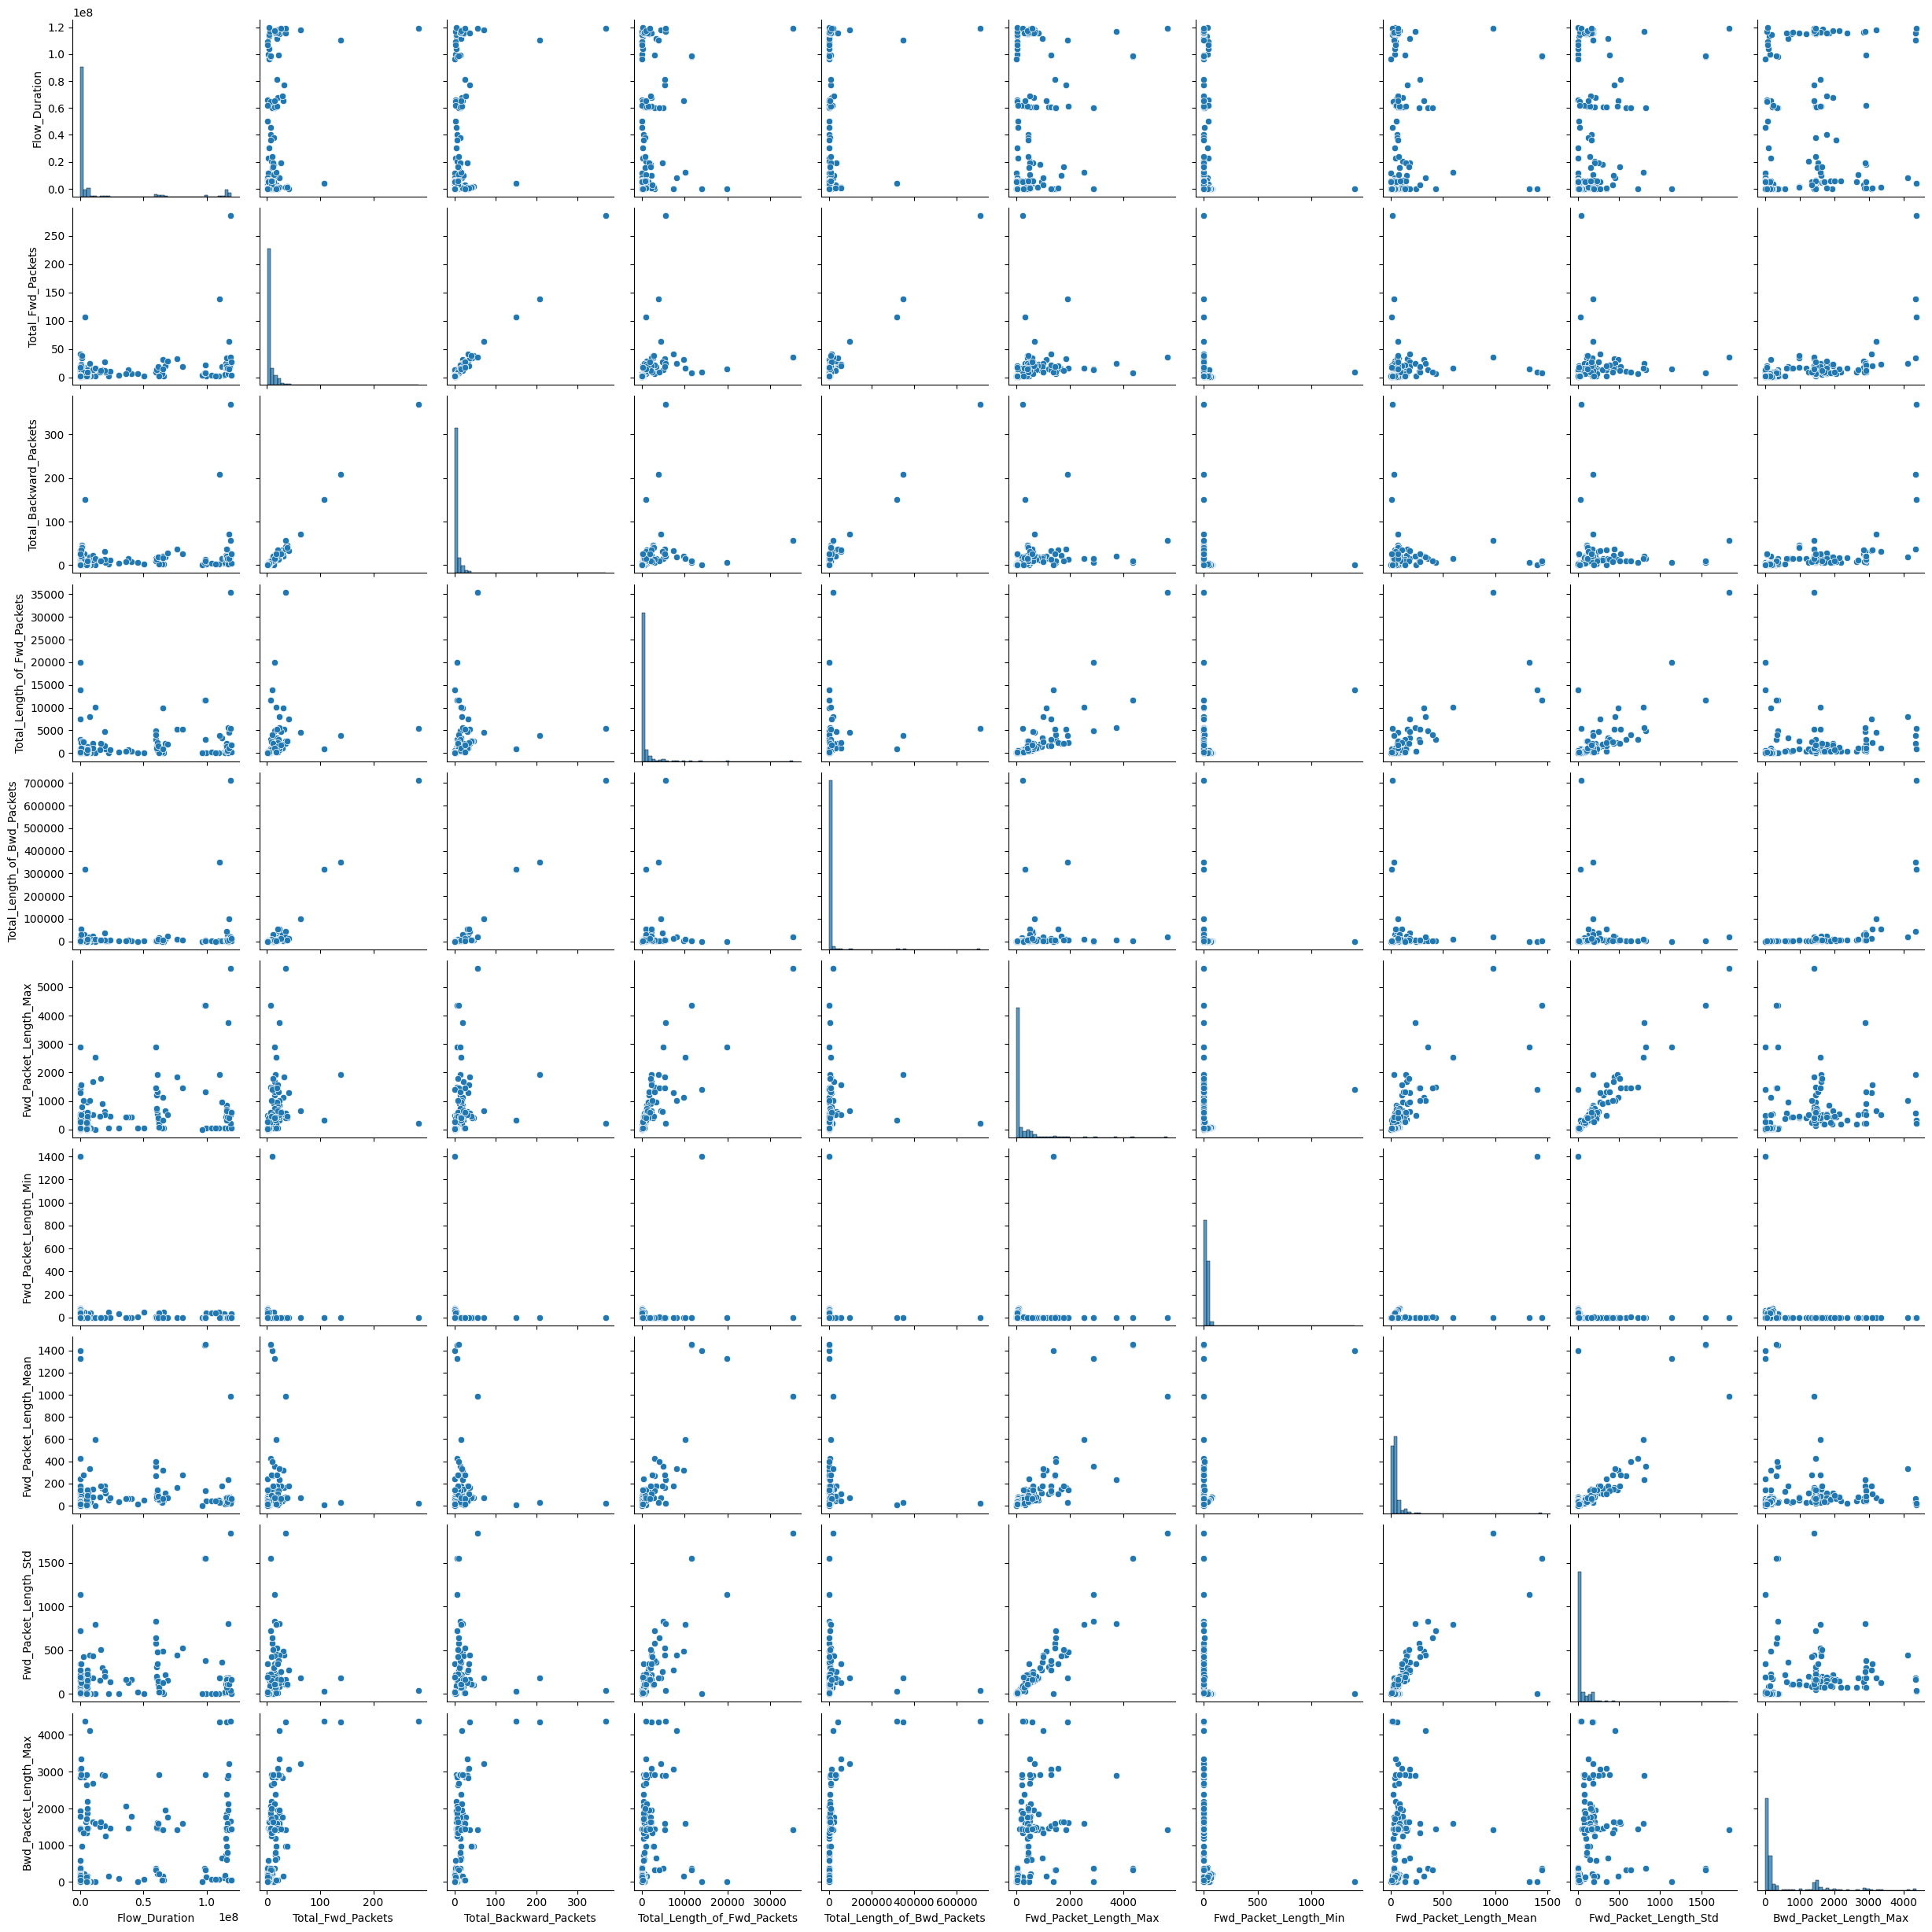

In [108]:
# doing pair plots for a subset of rows
import seaborn as sns
# doing pairplots for the first 10 columns
data_subset = data.iloc[1:501,1:11]
sns.pairplot(data_subset)

In [109]:
# correlation matrix
#data['Attack_Type']
corr_data = data.drop(columns = ["Attack_Type","Label"])
corr_data.corr().style.background_gradient(cmap='coolwarm')

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max,Bwd_Packet_Length_Min,Bwd_Packet_Length_Mean,Bwd_Packet_Length_Std,Flow_Bytes/s,Flow_Packets/s,Flow_IAT_Mean,Flow_IAT_Std,Flow_IAT_Max,Flow_IAT_Min,Fwd_IAT_Total,Fwd_IAT_Mean,Fwd_IAT_Std,Fwd_IAT_Max,Fwd_IAT_Min,Bwd_IAT_Total,Bwd_IAT_Mean,Bwd_IAT_Std,Bwd_IAT_Max,Bwd_IAT_Min,Fwd_Header_Length,Bwd_Header_Length,Fwd_Packets/s,Bwd_Packets/s,Min_Packet_Length,Max_Packet_Length,Packet_Length_Mean,Packet_Length_Std,Packet_Length_Variance,Average_Packet_Size,Avg_Fwd_Segment_Size,Avg_Bwd_Segment_Size,Fwd_Header_Length.1,Subflow_Fwd_Packets,Subflow_Fwd_Bytes,Subflow_Bwd_Packets,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
Destination_Port,1.000000,-0.147536,-0.005417,-0.003789,0.027912,-0.003744,0.036161,0.002506,0.080897,0.039871,-0.167283,-0.015919,-0.180102,-0.162404,0.094035,0.349220,-0.071579,-0.114947,-0.133372,-0.031787,-0.139819,-0.087902,-0.111955,-0.132298,-0.036190,-0.054438,-0.046842,-0.046756,-0.048761,-0.010544,-0.008230,-0.005826,0.336698,0.166120,-0.005348,-0.155196,-0.165063,-0.161076,-0.121673,-0.163580,0.080897,-0.180102,-0.008230,-0.005417,0.027912,-0.003789,-0.003744,-0.084644,0.170034,-0.001651,-0.072647,-0.041356,-0.011383,-0.041383,-0.039739,-0.126461,-0.027519,-0.130591,-0.121850
Flow_Duration,-0.147536,1.000000,0.025748,0.021848,0.052449,0.022583,0.145012,-0.113554,0.026130,0.163802,0.210364,-0.197090,0.244870,0.139772,-0.032859,-0.109197,0.378042,0.855389,0.963347,0.100836,0.999006,0.552654,0.859770,0.963585,0.165072,0.416607,0.342011,0.406563,0.423706,0.070025,0.031579,0.027948,-0.103651,-0.059991,-0.155194,0.218640,0.275494,0.209137,0.118644,0.262934,0.026130,0.244870,0.031579,0.025748,0.052449,0.021848,0.022588,-0.458036,-0.062871,0.015632,-0.246867,0.076877,0.084399,0.091399,0.060098,0.938873,0.177985,0.962964,0.909070
Total_Fwd_Packets,-0.005417,0.025748,1.000000,0.989329,0.505693,0.998836,0.082475,-0.004851,-0.003302,0.002463,0.039037,-0.006932,0.032544,0.007624,-0.000833,-0.003763,-0.014003,-0.008621,-0.008338,-0.010268,0.025056,-0.015269,-0.006536,-0.008290,-0.011720,0.039617,-0.004149,-0.005421,-0.002699,0.001661,0.986388,0.997787,-0.003504,-0.002406,-0.006570,0.039330,0.037158,0.016755,0.011604,0.033013,-0.003302,0.032544,0.986388,1.000000,0.505693,0.989329,0.998831,0.002267,0.001750,0.953347,-0.009391,0.004292,0.009394,0.006763,0.002503,-0.008738,0.000688,-0.008599,-0.008735
Total_Backward_Packets,-0.003789,0.021848,0.989329,1.000000,0.511462,0.991549,0.055731,-0.003245,-0.002090,0.003594,0.032586,-0.003617,0.027593,0.005532,-0.000532,-0.003358,-0.012195,-0.005916,-0.005335,-0.008792,0.021366,-0.011425,-0.002983,-0.005309,-0.009486,0.038442,-0.002770,-0.000940,0.002409,-0.001916,0.952993,0.994519,-0.003285,-0.001367,-0.004706,0.032773,0.036006,0.014883,0.008226,0.032673,-0.002090,0.027593,0.952993,0.989329,0.511462,1.000000,0.991538,-0.002706,0.000279,0.985590,-0.017981,-0.005875,0.002756,-0.004082,-0.006340,-0.004868,-0.004626,-0.005611,-0.004285
Total_Length_of_Fwd_Packets,0.027912,0.052449,0.505693,0.511462,1.000000,0.495595,0.379569,0.020671,0.349542,0.334650,0.041655,-0.027163,0.035899,0.021432,0.008126,-0.014851,-0.049401,-0.000043,-0.003993,-0.047105,0.049287,-0.042025,0.001361,-0.004138,-0.040241,0.110269,0.067504,0.033728,0.045624,0.087444,0.489244,0.510315,-0.014477,-0.006281,-0.003349,0.061676,0.082617,0.047090,0.019033,0.077940,0.349542,0.035899,0.489244,0.505693,1.000000,0.511462,0.495612,0.069813,0.127721,0.504218,-0.024287,0.033195,0.229870,0.089327,-0.016112,-0.008246,0.008027,-0.004843,-0.008951
Total_Length_of_Bwd_Packets,-0.003744,0.022583,0.998836,0.991549,0.495595,1.000000,0.073117,-0.003192,-0.006000,-0.00

### Performing Multivariate Analysis

In [110]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [111]:
# don't need to make blobs since we already have data
Xb = data_subset
print(Xb.shape)
yb = data['Attack_Type'][1:501]
print(yb.shape)

(500, 10)
(500,)


In [112]:
Xb

,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max
1,113594958.0,4.0,4.0,152.0,362.0,45.0,31.0,38.000000,8.082904,120.0
2,30485.0,1.0,1.0,81.0,209.0,81.0,81.0,81.000000,0.000000,209.0
3,30445.0,1.0,1.0,53.0,81.0,53.0,53.0,53.000000,0.000000,81.0
4,70860.0,1.0,1.0,56.0,72.0,56.0,56.0,56.000000,0.000000,72.0
5,99737370.0,3.0,3.0,124.0,310.0,44.0,38.0,41.333333,3.055050,129.0
...,...,...,...,...,...,...,...,...,...,...
497,116217007.0,16.0,14.0,519.0,802.0,435.0,0.0,32.437500,107.360433,796.0
498,117680023.0,15.0,15.0,1038.0,5115.0,406.0,0.0,69.200000,112.127606,1418.0
499,119229272.0,27.0,25.0,1821.0,10863.0,595.0,0.0,67.444444,160.289242,1448.0
500,74.0,2.0,1.0,31.0,6.0,31.0,0.0,15.500000,21.920310,6.0


In [113]:
# standardizing
Xb = Xb.values # numpy indexing instead
Xb = Xb - Xb.mean(axis=0)
Xb = Xb/Xb.std(axis=0)

type(Xb)

numpy.ndarray

In [114]:
# performing k-means clustering
# number of clusters = number of classes in label column
label_classes = len(set(data['Label']))
label_classes # 5
kmeans = KMeans(n_clusters=label_classes, init='k-means++', n_init=10)
kmeans_pred = kmeans.fit_predict(Xb)
kmeans_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,

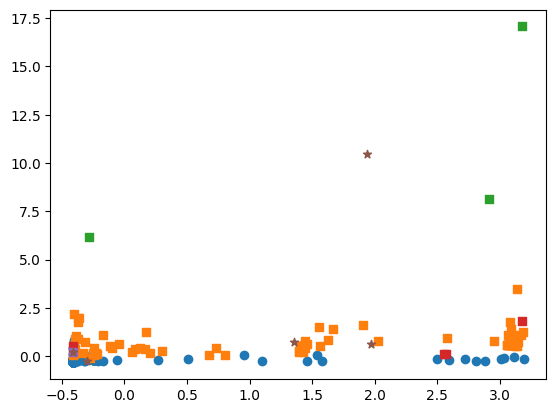

In [115]:
# visualizing results

plt.scatter(Xb[kmeans_pred==0, 0], Xb[kmeans_pred==0, 1], marker='o')
plt.scatter(Xb[kmeans_pred==1, 0], Xb[kmeans_pred==1, 1], marker='s')
plt.scatter(Xb[kmeans_pred==2, 0], Xb[kmeans_pred==2, 1], marker='s')
plt.scatter(Xb[kmeans_pred==3, 0], Xb[kmeans_pred==3, 1], marker='s')
plt.scatter(Xb[kmeans_pred==4, 0], Xb[kmeans_pred==4, 1], marker='s')
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*')

Index(['Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max',
       'Bwd_IAT_Min', 'Fwd_Header_Length', 'Bwd_Header_Length',
       'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length',
       'Max_Packet_Length'],
      dtype='object')


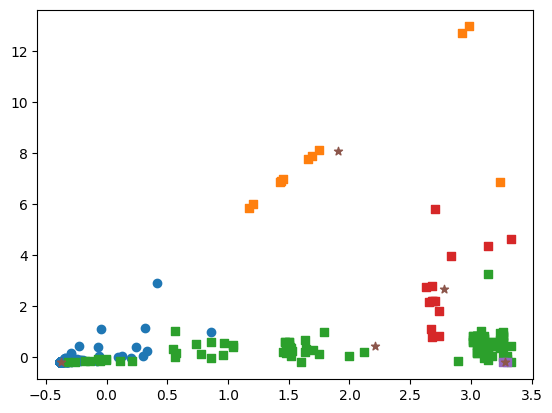

In [116]:
# doing k-means clustering with a subset of columns - 5 clusters (for the 5 label types)

# printing out the columns we are using in the subset
print(data.columns[25:36])

X1 = data.iloc[1:1001,25:36] 
X1 = X1.values # numpy indexing instead 
X1 = X1 - X1.mean(axis=0) 
X1 = X1/X1.std(axis=0) 

# clustering 
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10) 
kmeans_pred = kmeans.fit_predict(X1) 
# visualizing 
plt.scatter(X1[kmeans_pred==0, 0], X1[kmeans_pred==0, 1], marker='o') 
plt.scatter(X1[kmeans_pred==1, 0], X1[kmeans_pred==1, 1], marker='s')
plt.scatter(X1[kmeans_pred==2, 0], X1[kmeans_pred==2, 1], marker='s')
plt.scatter(X1[kmeans_pred==3, 0], X1[kmeans_pred==3, 1], marker='s')
plt.scatter(X1[kmeans_pred==4, 0], X1[kmeans_pred==4, 1], marker='s')
centroids = kmeans.cluster_centers_ 
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*')

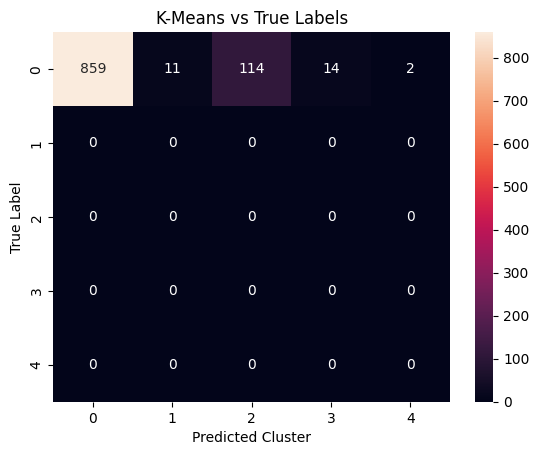

In [117]:
# checking if the predicted cluster index correlates with the class index
from sklearn.metrics import confusion_matrix

# true label subset - encoding them to be numerical
ys = pd.factorize(data['Label'][1:1001])[0]

# making the confusion matrix
cm = confusion_matrix(ys, kmeans_pred)

# plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.title('K-Means vs True Labels')
plt.show()

Index(['Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max',
       'Bwd_IAT_Min', 'Fwd_Header_Length', 'Bwd_Header_Length',
       'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length',
       'Max_Packet_Length'],
      dtype='object')


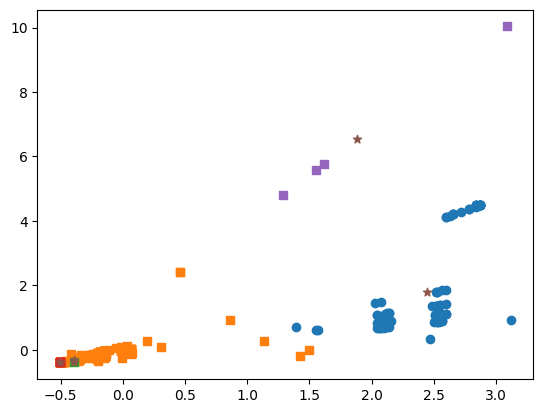

In [118]:
# doing k-means clustering with a subset of columns - 5 clusters (for the 5 label types)

# printing out the columns we are using in the subset
print(data.columns[25:36])

# randomly choosing rows for the subset - can't slice since there are many rows with the same
# response ordered together 
data_sample = data.sample(n=1000, random_state = 9182)

# standardizing
X1 = data_sample.iloc[:,25:36] 
X1 = X1.values # numpy indexing instead 
X1 = X1 - X1.mean(axis=0) 
X1 = X1/X1.std(axis=0) 

# clustering 
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10) 
kmeans_pred = kmeans.fit_predict(X1) 
# visualizing 
plt.scatter(X1[kmeans_pred==0, 0], X1[kmeans_pred==0, 1], marker='o') 
plt.scatter(X1[kmeans_pred==1, 0], X1[kmeans_pred==1, 1], marker='s')
plt.scatter(X1[kmeans_pred==2, 0], X1[kmeans_pred==2, 1], marker='s')
plt.scatter(X1[kmeans_pred==3, 0], X1[kmeans_pred==3, 1], marker='s')
plt.scatter(X1[kmeans_pred==4, 0], X1[kmeans_pred==4, 1], marker='s')
centroids = kmeans.cluster_centers_ 
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*')

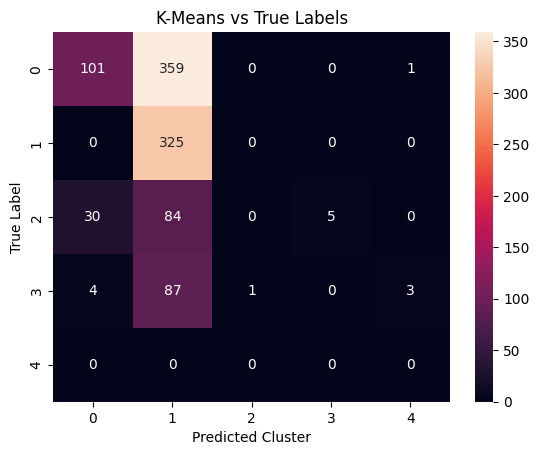

In [119]:
from sklearn.metrics import confusion_matrix

# true label subset - encoding them to be numerical
ys = pd.factorize(data_sample['Label'])[0]

# making the confusion matrix
cm = confusion_matrix(ys, kmeans_pred)

# plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.title('K-Means vs True Labels')
plt.show()

8. Data Preprocessing - Hillary 

In [120]:
# Required Libraries for Preprocessing 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [121]:
# Drop label column since we are doing unsupervised learning 
# Attack_Type is the new y or respose variable, but since we are doing unsupervised learning, we will not be using it for training the model. We will use it for evaluation purposes only.

processed_data = data.drop(columns = ['Label'])
processed_data.head()

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Attack_Type
0,55109.0,17.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,53.0,113594958.0,4.0,4.0,152.0,362.0,45.0,31.0,38.0,8.082904,...,32.0,240.0,0.0,240.0,240.0,114000000.0,0.0,114000000.0,114000000.0,0
2,53.0,30485.0,1.0,1.0,81.0,209.0,81.0,81.0,81.0,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,53.0,30445.0,1.0,1.0,53.0,81.0,53.0,53.0,53.0,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,53.0,70860.0,1.0,1.0,56.0,72.0,56.0,56.0,56.0,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [122]:
# Splitting the data into training and testing sets 

# X is the main dataframe without the response variable Attack_Type 
# y is the response variable Attack_Type 
X = processed_data.drop(columns = ['Attack_Type'])
y = processed_data['Attack_Type']

# I folllowed the same parameters that we did in class for choosing test and train sizes 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=9182)

In [123]:
# Standardize and normalization of the data 
scaler = StandardScaler()

# Only using X training and X test for scaling to build the model to avoid data leakage. 
# Y is not used for scaling since it is the response variable and we are doing unsupervised learning. 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print lines of x test and x train to check if they are scaled 
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)


X_train_scaled shape: (37019, 59)
X_test_scaled shape: (12340, 59)


9. Feature Engineering - Hillary  

In [124]:
# Required Libraries for Feature Engineering 
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import r2_score, mean_squared_error

In [125]:
# L1 Lasso-based feature selection 
lasso_regression = Lasso(alpha=0.01)

# Train the laso regression model on the training dataset 
lasso_regression.fit(X_train_scaled, y_train)

# Model-based feature selection using Lasso regression
model = SelectFromModel(lasso_regression, prefit=True)

In [126]:
# Perform feature selection on the training and testing data
X_train_selected = model.transform(X_train_scaled)
X_test_selected = model.transform(X_test_scaled)

# Printing the shapes of the selected features for training and testing data 
print('X_train_selected shape:', X_train_selected.shape)
print('X_test_selected shape:', X_test_selected.shape)


X_train_selected shape: (37019, 14)
X_test_selected shape: (12340, 14)


In [127]:
# Printing the selected features 
selected_features = X.columns[model.get_support()]
print('Selected Features:', selected_features)

Selected Features: Index(['Destination_Port', 'Total_Length_of_Fwd_Packets',
       'Fwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Flow_IAT_Mean',
       'Flow_IAT_Max', 'Bwd_IAT_Std', 'Min_Packet_Length', 'Packet_Length_Std',
       'Average_Packet_Size', 'Subflow_Fwd_Bytes', 'Init_Win_bytes_backward',
       'min_seg_size_forward', 'Active_Mean'],
      dtype='object')


In [128]:
# Printing the model coefficients for the selected features
selected_coefficients = lasso_regression.coef_[model.get_support()]
print('Selected Coefficients:', selected_coefficients)

Selected Coefficients: [-0.09268509 -0.00235442 -0.01573524 -0.11909869  0.02561706  0.03000672
  0.01181338 -0.00261488  0.03393582  0.04686828 -0.00137655 -0.0108083
  0.04874472  0.0107916 ]


In [129]:
# Performing model fitting and evaluation using the selected features. 
lasso_regression.fit(X_train_selected, y_train)
y_pred = lasso_regression.predict(X_test_selected)


In [130]:
# Computing the r2-score and MSE values for the model with selected features
r2_score = r2_score(y_test, y_pred)
print('R2 Score:', r2_score)

mean_squared_error = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mean_squared_error)


R2 Score: 0.5915372676188237
Mean Squared Error: 0.03628412662941388


10. Processed Data Loading - Hillary 

In [131]:
# Write processed data to new csv file
processed_data.to_csv('processed_data.csv', index=False)

# Write test and train data to new csv files 
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
